<a href="https://colab.research.google.com/github/valeriaramirezjimenez10-crypto/Analitica-de-negocios/blob/main/Reto_2_Arboles_de_decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso de Estudio** Predicción de enfermedad cardíaca

Una institución de salud desea predecir la presencia de enfermedad cardíaca en pacientes a partir de variables clínicas básicas. Para ello se utilizará un modelo de árbol de decisión que permita identificar patrones y factores de riesgo.

El objetivo es construir un modelo que, usando información del paciente (edad, presión arterial y BMI), clasifique si el paciente presenta o no la enfermedad, facilitando la detección temprana y la toma de decisiones médicas.

**Para este proceso vamos a utilizar las variables:**

**Edad:** Indica el numero de años que posee una persona o el tiempo que lleva en el sistema financiero.
**Systolic:** Presión arterial sistólica en mmHg (numérica continua), que mide la presión cuando el corazón se contrae. Valores altos se asocian con hipertensión.
**Distolic:** Presión arterial diastólica en mmHg (numérica continua), que refleja la presión cuando el corazón está en reposo. Complementa la evaluación de la presión arterial.
**BMI:**
Índice de Masa Corporal del paciente (numérica continua) que relaciona peso y estatura. Un BMI elevado indica mayor riesgo cardiovascular.



0. Se procede con la carga de las librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

In [ ]:
1. Se proxcede con la carga de datos

In [ ]:
nxl="/content/2. HeartDisease.xlsx"
XDB=pd.read_excel(nxl,sheet_name=0)
XD=XDB.iloc[:,[1,2,3,4]] #Variables de entrada
yd=XDB.iloc[:,0] #Variable de salida

2. Se implementa el modelo del arboles

In [ ]:
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD, yd) #El modelo busca la relación entrada/salida
ydp=mar.predict(XD) #Esto es lo que pronostica el modelo

#Se construye la matriz de confusión
cm=confusion_matrix(yd, ydp)
display(cm)
VN=cm[0,0];FP=cm[0,1];FN=cm[1,0];VP=cm[1,1]
#metricas de desempeño
exactitud=((VP+VN)/(VP+VN+FP+FN))*100
print("La exactitud es:",exactitud)
sensibilidad=(VP/(VP+FN))*100
print("La sensibilidad es:",sensibilidad)
especificidad=(VN/(VN+FP))*100
print("La especificidad es:",especificidad)
precisión=(VP/(VP+FP))*100
print("La precisión es:",precisión)

array([[63, 10],
       [20, 87]])

La exactitud es: 83.33333333333334
La sensibilidad es: 81.30841121495327
La especificidad es: 86.3013698630137
La precisión es: 89.69072164948454


3. Despliegue del arbol de decision

In [ ]:
from sklearn.tree import export_graphviz #Exporta los datos a un grafico
from pydotplus import graph_from_dot_data #Garaficador
vs=["Age", "Systolic", "Diastolic", "BMI"] #Título del árbol
dot_data=export_graphviz(mar,feature_names=vs) #Exportar graficco PDF
graph=graph_from_dot_data(dot_data) # Hacemos el Graficado
graph.write_png("arbol.png")

#Por la Izquierda viajan los positivo y por la derecha los negativos

True

**Analisis de resultados:** De acuerdo con los resultados obtenidos, el modelo de árbol de decisión alcanzó una **exactitud** del 83.33%, lo que indica que clasifica correctamente aproximadamente 83 de cada 100 casos evaluados. En cuanto a la **sensibilidad**, el modelo logró identificar correctamente el 81.31% de los pacientes que realmente presentan la enfermedad, mostrando una buena capacidad para detectar casos positivos. Por su parte, **la especificidad** fue del 86.30%, lo que evidencia que el modelo reconoce adecuadamente a la mayoría de los pacientes sanos. Finalmente, la **precisión** del 89.69% indica que, cuando el modelo predice la presencia de enfermedad cardíaca, acierta en cerca de 9 de cada 10 casos, lo que refleja un buen desempeño predictivo general.

De acuerdo con **el árbol de decisión**, se observa que la variable más determinante en la clasificación del riesgo de enfermedad cardíaca es la edad, siendo el primer punto de corte en 54.5 años. En el total de 180 pacientes analizados, 107 presentan enfermedad y 73 no. Al segmentar por edad, se identifica que en el grupo mayor a 54.5 años (58 pacientes), 52 presentan enfermedad, lo que representa aproximadamente un 89.6% de incidencia, evidenciando un nodo con alta pureza (gini = 0.185). Particularmente, en pacientes mayores de 69.5 años se identifica un nodo completamente puro (gini = 0) con 2 de 2 pacientes diagnosticados con enfermedad (100%).

En contraste, en el grupo de pacientes con edad menor o igual a 54.5 años (122 individuos), el comportamiento es más heterogéneo (67 sin enfermedad y 55 con enfermedad), por lo que el modelo requiere variables adicionales como BMI y presión arterial para refinar la clasificación. Por ejemplo, en pacientes jóvenes con presión sistólica mayor a 123 mmHg se identifica un nodo puro con 12 de 12 pacientes con enfermedad (100%), lo cual evidencia una regla de alto riesgo clínico. Asimismo, combinaciones específicas de presión diastólica elevada también incrementan significativamente la probabilidad de diagnóstico positivo.

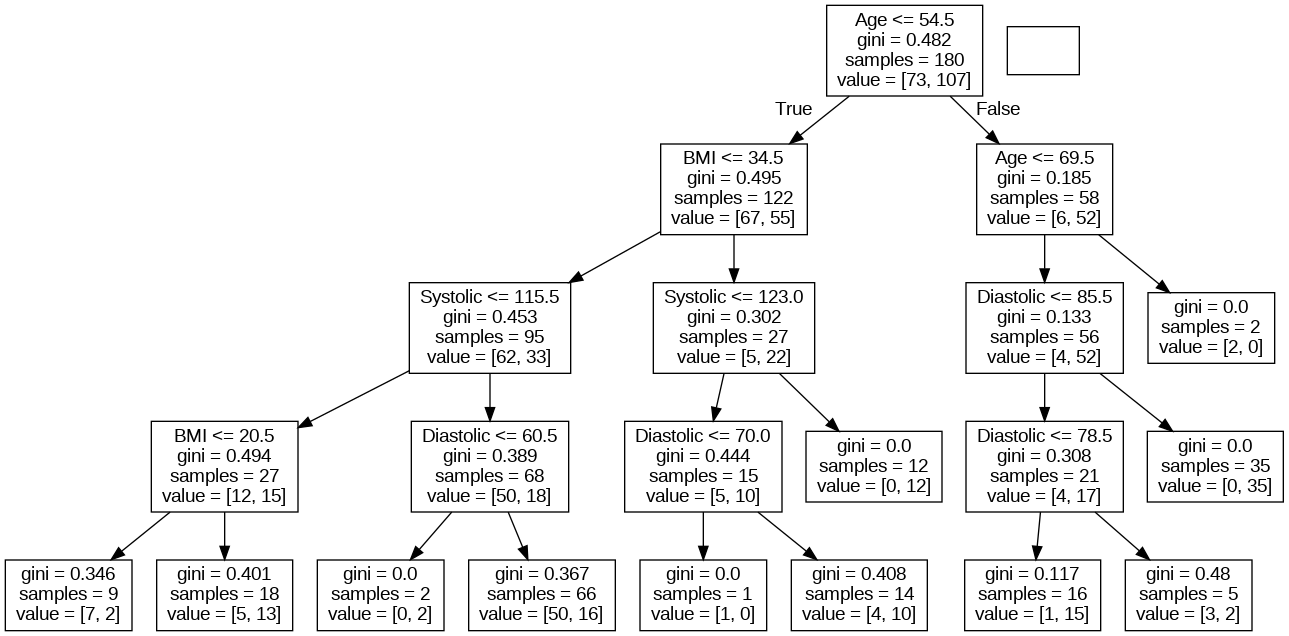

4. Nuevos pacientes

Los valores mostrados representan la predicción del modelo para cada nuevo paciente: '0' indica que el paciente no tiene enfermedad cardíaca, y '1' indica que sí la tiene.

In [ ]:
nxl = "/content/2. HeartDisease.xlsx"
XDB1_new = pd.read_excel(nxl, sheet_name=1)
XD_new_patients = XDB1_new.iloc[:, [1, 2, 3, 4]] # Variables de entrada para nuevos pacientes

# Prediccion nuevos pacientes
ydp_new_correct = mar.predict(XD_new_patients)
display(ydp_new_correct)

array([0, 0, 0, 1, 1, 1, 1, 1])

In [ ]:
# Combinar las predicciones en la tabla
XD_new_patients['Prediction'] = ydp_new_correct
display(XD_new_patients)

,Age,Systolic,Diastolic,BMI,Prediction
0,33,120,64,33,0
1,55,115,81,32,0
2,51,130,70,20,0
3,65,101,63,18,1
4,62,109,110,38,1
5,60,130,69,35,1
6,61,124,95,36,1
7,53,150,81,41,1
